# Weather-Driven Electricity Demand Prediction
Detailed notebook

In [17]:
import pandas as pd
df = pd.read_csv("PSP_Weather_Merged_EDA_Cleaned.csv")
df.head()

,Date,State,Max_Demand_Met_MW,Shortage_MW,Energy_Met_MU,Drawal_Schedule_MU,OD_UD_MU,Max_OD_MW,Energy_Shortage_MU,Temp_Max,Temp_Min,Temp_Avg,Humidity,Rainfall,Year,Month,Weekday,Season
0,2023-04-01,Andhra Pradesh,10979.0,0.0,220.36,77.26,-0.34,383.0,0.0,33.100000,25.200000,29.150000,77.666667,3.933333,2023,4,Saturday,Summer
1,2023-04-02,Andhra Pradesh,10824.0,0.0,211.45,76.63,-1.41,382.0,0.0,33.500000,24.800000,29.150000,77.000000,2.900000,2023,4,Sunday,Summer
2,2023-04-03,Andhra Pradesh,10838.0,0.0,219.17,77.54,-0.09,548.0,0.0,34.333333,25.166667,29.750000,76.333333,0.833333,2023,4,Monday,Summer
3,2023-04-04,Andhra Pradesh,11076.0,0.0,225.07,87.67,-0.41,667.0,0.0,34.033333,25.933333,29.983333,74.666667,2.200000,2023,4,Tuesday,Summer
4,2023-04-05,Andhra Pradesh,11451.0,0.0,227.39,81.14,0.21,401.0,0.0,35.666667,25.500000,30.583333,73.666667,0.200000,2023,4,Wednesday,Summer


## Preprocessing

Top features by absolute correlation with Max_Demand_Met_MW : ['Temp_Max', 'Temp_Avg', 'Temp_Min', 'Humidity', 'Rainfall']
Saved combined scatter/regression figure to top_features_scatter_regression.png
Saved combined scatter/regression figure to top_features_scatter_regression.png


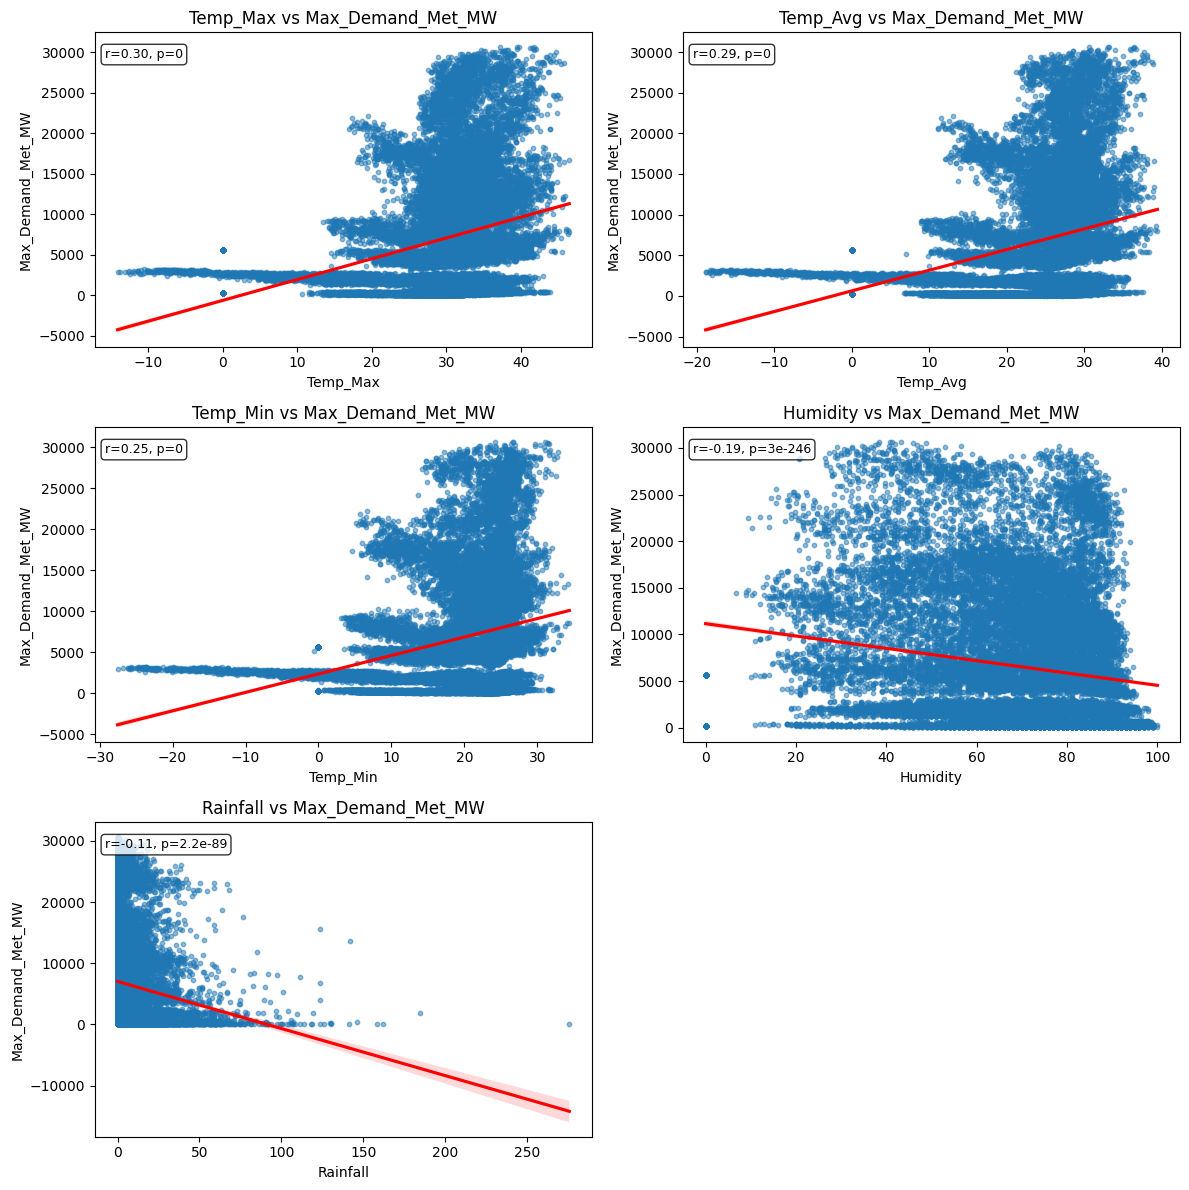

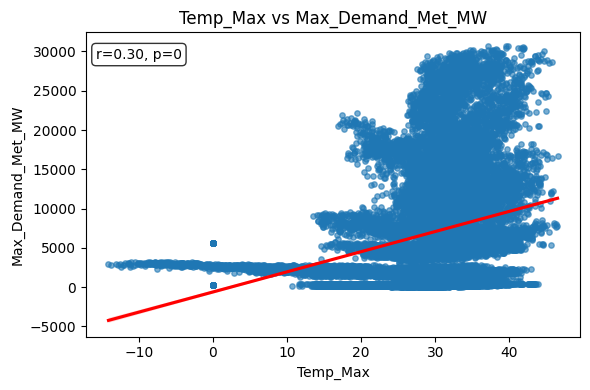

Saved scatter_reg_Temp_Max.png


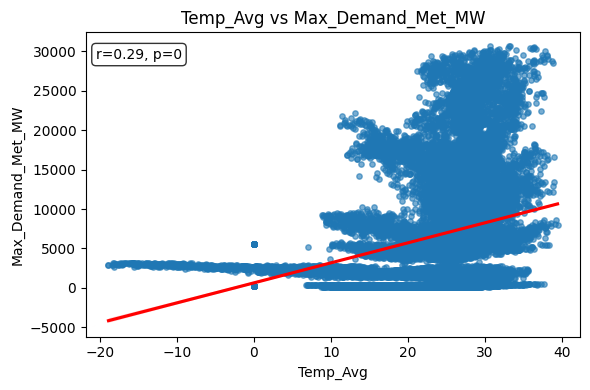

Saved scatter_reg_Temp_Avg.png


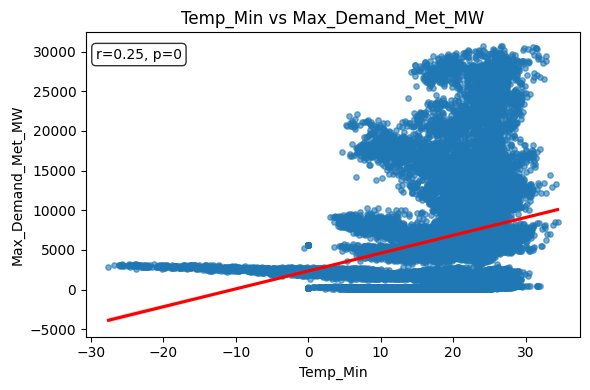

Saved scatter_reg_Temp_Min.png


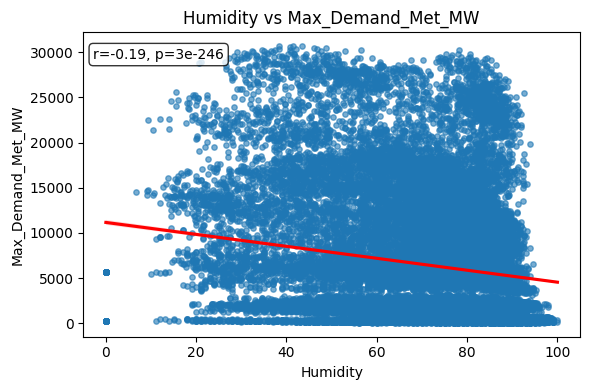

Saved scatter_reg_Humidity.png


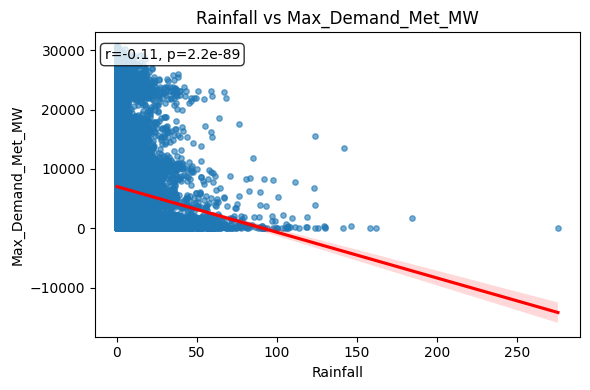

Saved scatter_reg_Rainfall.png


In [18]:
# Scatter + regression plots for top features vs demand
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
df = pd.read_csv('PSP_Weather_Merged_EDA_Cleaned.csv').reset_index(drop=True)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    # recreate cyclical features if present in preprocessing
    df['month'] = df['Date'].dt.month
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

TARGET = 'Max_Demand_Met_MW'
if TARGET not in df.columns:
    raise RuntimeError(f"Target column '{TARGET}' not found in CSV.")

# Identify candidate feature columns (weather-related heuristics)
patterns = ['temp','temperature','humidity','wind','pressure','rain','precip','solar','irradiance']
candidate_feats = [c for c in df.columns if any(p in c.lower() for p in patterns) and pd.api.types.is_numeric_dtype(df[c])]
# fallback: numeric columns excluding target, Date, State
if not candidate_feats:
    candidate_feats = [c for c in df.select_dtypes(include=[np.number]).columns if c not in [TARGET, 'Date', 'State']]
    candidate_feats = [c for c in candidate_feats if c.lower() not in ('index','unnamed: 0')]

# Compute global Pearson correlation (abs) with target and pick top features
corrs = {}
for f in candidate_feats:
    try:
        if df[f].nunique() <= 1:
            corrs[f] = 0.0
        else:
            cor = df[f].corr(df[TARGET])
            corrs[f] = 0.0 if pd.isna(cor) else float(cor)
    except Exception:
        corrs[f] = 0.0

# sort by absolute correlation magnitude
sorted_feats = sorted(corrs.items(), key=lambda kv: abs(kv[1]), reverse=True)
top_n = min(6, len(sorted_feats))
top_features = [f for f,_ in sorted_feats[:top_n]]
print('Top features by absolute correlation with', TARGET, ':', top_features)

if not top_features:
    print('No features available for plotting.')
else:
    # Create subplots (2 columns)
    ncols = 2
    nrows = math.ceil(len(top_features)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows))
    axes_flat = np.array(axes).reshape(-1) if hasattr(axes, 'reshape') else np.array([axes]).reshape(-1)
    out_dir_combined = 'top_features_scatter_regression.png'
    last_i = -1
    for i, feat in enumerate(top_features):
        last_i = i
        ax = axes_flat[i]
        sub = df[[feat, TARGET]].dropna()
        # skip if insufficient variation
        if sub.shape[0] < 3 or sub[feat].nunique() <= 1:
            ax.text(0.5, 0.5, f'Insufficient data for {feat}', ha='center')
            ax.set_axis_off()
            continue
        sns.regplot(x=feat, y=TARGET, data=sub, scatter_kws={'s':10,'alpha':0.5}, line_kws={'color':'red'}, ax=ax)
        # compute Pearson r and annotate
        try:
            r, p = stats.pearsonr(sub[feat].astype(float), sub[TARGET].astype(float))
            ax.annotate(f'r={r:.2f}, p={p:.2g}', xy=(0.02, 0.95), xycoords='axes fraction', va='top', fontsize=9, bbox=dict(boxstyle='round', fc='w', alpha=0.8))
        except Exception:
            pass
        ax.set_title(f'{feat} vs {TARGET}')
    # hide any unused subplots
    total_axes = len(axes_flat)
    for j in range(last_i+1, total_axes):
        try:
            axes_flat[j].set_visible(False)
        except Exception:
            pass
    plt.tight_layout()
    fig.savefig(out_dir_combined, dpi=150, bbox_inches='tight')
    print(f'Saved combined scatter/regression figure to {out_dir_combined}')
    plt.show()
    # Also save individual plots for each top feature
    for feat in top_features:
        sub = df[[feat, TARGET]].dropna()
        if sub.shape[0] < 3 or sub[feat].nunique() <= 1:
            print(f'Skipping individual plot for {feat} (insufficient data)')
            continue
        plt.figure(figsize=(6,4))
        ax = sns.regplot(x=feat, y=TARGET, data=sub, scatter_kws={'s':15,'alpha':0.6}, line_kws={'color':'red'})
        try:
            r, p = stats.pearsonr(sub[feat].astype(float), sub[TARGET].astype(float))
            ax.annotate(f'r={r:.2f}, p={p:.2g}', xy=(0.02, 0.95), xycoords='axes fraction', va='top', fontsize=10, bbox=dict(boxstyle='round', fc='w', alpha=0.8))
        except Exception:
            pass
        plt.title(f'{feat} vs {TARGET}')
        out_single = f'scatter_reg_{feat}.png'
        plt.tight_layout()
        plt.savefig(out_single, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved {out_single}')


Per-fold results:


,fold,model,R2,RMSE,MAE
0,0,LinearRegression,0.991565,590.765979,436.760211
1,1,LinearRegression,0.987921,640.518199,374.208365
2,2,LinearRegression,0.994499,714.880030,481.992132
3,3,LinearRegression,0.990301,259.996294,197.709379
4,4,LinearRegression,0.991897,640.868051,431.070005
5,5,LinearRegression,0.983112,1095.552617,656.564168
6,0,RandomForest,0.789183,2953.358281,1740.797193
7,1,RandomForest,0.989110,608.189909,413.846459
8,2,RandomForest,0.990221,953.146764,555.558271
9,3,RandomForest,0.994380,197.918970,108.714664


Mean cross-fold metrics (lower RMSE better):


,model,R2,RMSE,MAE
0,LinearRegression,0.989882,657.096862,429.717377
1,RandomForest,0.957143,1044.884554,619.491394
3,XGBoost,0.949317,1185.846465,690.968702
2,SVR,-0.299453,7708.766284,5607.513029


Saved summary to time_series_cv_results.csv


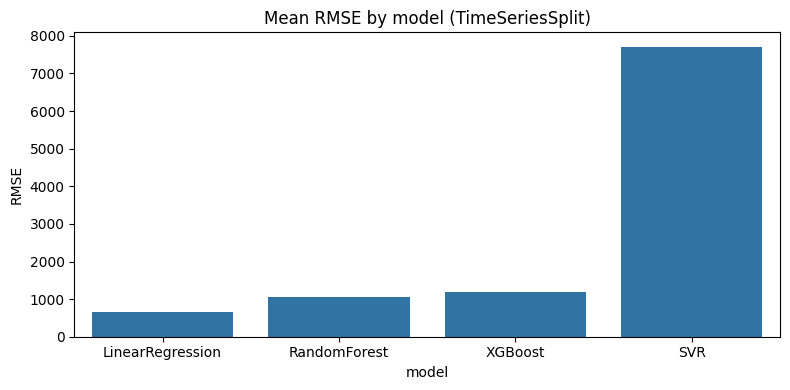

Best model by mean RMSE: LinearRegression


In [19]:
# TimeSeriesSplit-based evaluation across folds, summary metrics and simple plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from xgboost import XGBRegressor
    has_xgb = True
except Exception:
    has_xgb = False

# Load processed features if not present in memory
if 'X_processed' in globals():
    X_arr = np.asarray(X_processed)
else:
    X_arr = np.load('X_processed.npy', allow_pickle=True)

if 'y' in globals() and y is not None:
    y_arr = np.asarray(y)
else:
    y_arr = np.asarray(pd.read_csv('PSP_Weather_Merged_EDA_Cleaned.csv')['Max_Demand_Met_MW'])

assert X_arr.shape[0] == len(y_arr), 'Feature/target length mismatch'

tscv = TimeSeriesSplit(n_splits=6)
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'SVR': SVR()
}
if has_xgb:
    models['XGBoost'] = XGBRegressor(random_state=42, verbosity=0)

# Optional small grid for RandomForest (toggle by setting DO_TUNE=True)
DO_TUNE = False
rf_grid = {'n_estimators': [50,100], 'max_depth': [None, 10, 20]}

fold_results = []
fitted_models = {name: [] for name in models.keys()}
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_arr)):
    X_train, X_test = X_arr[train_idx], X_arr[test_idx]
    y_train, y_test = y_arr[train_idx], y_arr[test_idx]
    for name, model in models.items():
        m = model
        try:
            if name == 'RandomForest' and DO_TUNE:
                g = GridSearchCV(RandomForestRegressor(random_state=42), rf_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
                g.fit(X_train, y_train)
                m = g.best_estimator_
            else:
                m = clone(model) if 'clone' in globals() else model.__class__(**getattr(model,'get_params',lambda: {})())
                m.fit(X_train, y_train)
            preds = m.predict(X_test)
            r2 = float(r2_score(y_test, preds))
            rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
            mae = float(mean_absolute_error(y_test, preds))
            fold_results.append({'fold': fold, 'model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
            fitted_models[name].append(m)
        except Exception as ex:
            fold_results.append({'fold': fold, 'model': name, 'error': str(ex)})

results_df = pd.DataFrame(fold_results)
print('Per-fold results:')
display(results_df.sort_values(['model','fold']).reset_index(drop=True))

# Aggregate metrics by model
agg = results_df.groupby('model').agg({'R2':'mean', 'RMSE':'mean', 'MAE':'mean'}).reset_index()
agg = agg.sort_values('RMSE')
print('Mean cross-fold metrics (lower RMSE better):')
display(agg)
agg.to_csv('time_series_cv_results.csv', index=False)
print('Saved summary to time_series_cv_results.csv')

# Simple visualization: RMSE per model
plt.figure(figsize=(8,4))
sns.barplot(data=agg, x='model', y='RMSE')
plt.title('Mean RMSE by model (TimeSeriesSplit)')
plt.tight_layout()
plt.savefig('cv_rmse_by_model.png')
plt.show()

# Choose best model by RMSE (lowest)
best_name = agg.iloc[0]['model']
print('Best model by mean RMSE:', best_name)
# store results and fitted models dict for later cells
globals()['cv_results_df'] = results_df
globals()['cv_summary'] = agg
globals()['fitted_models_cv'] = fitted_models
globals()['best_model_name_cv'] = best_name

# Note: fitted_models_cv stores models trained on each fold; we'll retrain the chosen estimator on full data below

## Feature/Target Selection

In [20]:
# Feature/target selection — use preprocessed data exposed by the preprocessing cell
# X (raw features) and y are available from the preprocessing step as globals: X, y
if 'X_processed_df' in globals():
    print('Using X_processed_df (DataFrame)')
    X_df = X_processed_df
    X_arr = X_processed
elif 'X_processed' in globals():
    X_arr = X_processed
    X_df = None
else:
    X_arr = np.load('X_processed.npy', allow_pickle=True)
    X_df = None

if 'y' in globals() and y is not None:
    y_arr = y
else:
    y_arr = pd.read_csv('PSP_Weather_Merged_EDA_Cleaned.csv')['Max_Demand_Met_MW']

print('Shapes: X ->', getattr(X_arr, 'shape', None), ' y ->', getattr(y_arr, 'shape', None))
globals()['X_arr'] = X_arr
globals()['X_df'] = X_df
globals()['y_arr'] = np.asarray(y_arr)


Shapes: X -> (31177, 66)  y -> (31177,)


In [21]:
# Robust train/test split that prefers available preprocessed variables
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Determine feature matrix (try several names in order of preference)
if 'X_processed' in globals():
    X_for_split = globals().get('X_processed')
elif 'X_arr' in globals():
    X_for_split = globals().get('X_arr')
elif 'X_processed_df' in globals():
    X_for_split = globals().get('X_processed_df').values
else:
    try:
        X_for_split = np.load('X_processed.npy', allow_pickle=True)
    except Exception:
        X_for_split = None

# Determine target vector
if 'y' in globals() and globals().get('y') is not None:
    y_for_split = globals().get('y')
elif 'y_arr' in globals():
    y_for_split = globals().get('y_arr')
else:
    try:
        y_for_split = pd.read_csv('PSP_Weather_Merged_EDA_Cleaned.csv')['Max_Demand_Met_MW'].values
    except Exception:
        y_for_split = None

if X_for_split is None or y_for_split is None:
    raise RuntimeError('Could not find suitable X and/or y for train_test_split. Run preprocessing/training cells first.')

# Ensure numpy arrays
X_for_split = np.asarray(X_for_split)
y_for_split = np.asarray(y_for_split)

# Do the split and expose variables to globals for subsequent cells
X_train, X_test, y_train, y_test = train_test_split(X_for_split, y_for_split, test_size=0.2, random_state=42)
globals()['X_train'] = X_train
globals()['X_test'] = X_test
globals()['y_train'] = y_train
globals()['y_test'] = y_test
print('Shapes: X_train', getattr(X_train, 'shape', None), 'X_test', getattr(X_test, 'shape', None), 'y_train', getattr(y_train, 'shape', None), 'y_test', getattr(y_test, 'shape', None))

Shapes: X_train (24941, 66) X_test (6236, 66) y_train (24941,) y_test (6236,)


In [22]:
# Safely inspect y_train whether it's a pandas Series or numpy array
import numpy as np
from IPython.display import display

if 'y_train' not in globals():
    print('y_train is not defined — run the train/test split cell first.')
else:
    yt = globals().get('y_train')
    print('y_train type:', type(yt))
    try:
        if hasattr(yt, 'head'):
            display(yt.head())
        else:
            arr = np.asarray(yt)
            print('y_train shape:', getattr(arr, 'shape', None))
            print('first 10 values:', arr[:10])
    except Exception as e:
        print('Could not display y_train:', e)

y_train type: <class 'numpy.ndarray'>
y_train shape: (24941,)
first 10 values: [  151.   162. 13135.  2466. 14700.   236. 18372.   189. 25994.  2466.]


## Model Training & Evaluation

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
try:
    from xgboost import XGBRegressor
    has_xgb = True
except Exception:
    has_xgb = False
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR()
}
if has_xgb:
    models['XGBoost'] = XGBRegressor()

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "R2": float(r2_score(y_test, preds)),
        "RMSE": float(np.sqrt(mean_squared_error(y_test, preds))),
        "MAPE": float(mean_absolute_percentage_error(y_test, preds))
    }

results

{'Linear Regression': {'R2': 0.99621852415649,
  'RMSE': 454.2412435188631,
  'MAPE': 0.24138426046319758},
 'Random Forest': {'R2': 0.9986159389437038,
  'RMSE': 274.81062723377164,
  'MAPE': 0.028613318462261828},
 'SVR': {'R2': 0.08565557380979161,
  'RMSE': 7063.35135039826,
  'MAPE': 5.1656904935757},
 'XGBoost': {'R2': 0.9986454144145782,
  'RMSE': 271.86864570725044,
  'MAPE': 0.03753184761973767}}

## Best Model Selection

In [24]:
best = max(results, key=lambda x: results[x]["R2"])
best

'XGBoost'

## Train Best Model Fully

In [ ]:
# Train selected best model on the full dataset and save it
import numpy as np
import pandas as pd
import pickle

if 'best' not in globals():
    raise RuntimeError('Best model name not found — run the best-selection cell first.')
if 'models' not in globals():
    raise RuntimeError('Models dictionary not found — ensure the model definitions cell has run.')
if best not in models:
    raise RuntimeError(f"Selected best model '{best}' not found in models dict. Available: {list(models.keys())}")
est = models[best]
# Find X and y (preferred variables or fallbacks)
X_full = globals().get('X_processed') if 'X_processed' in globals() else globals().get('X_arr') if 'X_arr' in globals() else None
if X_full is None:
    try:
        X_full = np.load('X_processed.npy', allow_pickle=True)
    except Exception:
        X_full = None
y_full = globals().get('y') if 'y' in globals() and globals().get('y') is not None else globals().get('y_arr') if 'y_arr' in globals() else None
if y_full is None:
    try:
        y_full = pd.read_csv('PSP_Weather_Merged_EDA_Cleaned.csv')['Max_Demand_Met_MW'].values
    except Exception:
        y_full = None
if X_full is None or y_full is None:
    raise RuntimeError('Could not find suitable X and/or y to train the full model. Run preprocessing cells first.')
X_full = np.asarray(X_full)
y_full = np.asarray(y_full).ravel()
if X_full.shape[0] != len(y_full):
    raise RuntimeError(f'Feature/target length mismatch: X rows={X_full.shape[0]} vs y length={len(y_full)}')
# Fit and persist
est.fit(X_full, y_full)
globals()['best_model'] = est
with open('demand_model.pkl', 'wb') as f:
    pickle.dump(est, f)
print(f'Trained and saved best model: {best} (n={X_full.shape[0]}) -> demand_model.pkl')

SyntaxError: invalid syntax (2326919692.py, line 51)

In [ ]:
# State-level prediction: which State has the highest predicted demand?
import pandas as pd
import numpy as np
import joblib
import pickle
from IPython.display import display

# Load preprocessing pipeline and trained model
try:
    pipeline = joblib.load('preprocess.joblib')
except Exception as e:
    raise RuntimeError('Could not load preprocess.joblib. Run the preprocessing cell first.') from e

try:
    model = pickle.load(open('demand_model.pkl', 'rb'))
except Exception as e:
    raise RuntimeError('Could not load demand_model.pkl. Train and save the model first.') from e

# Read raw data and create the same engineered date features used in preprocessing
df_raw = pd.read_csv('PSP_Weather_Merged_EDA_Cleaned.csv').dropna().reset_index(drop=True)
if 'Date' in df_raw.columns:
    df_raw['Date'] = pd.to_datetime(df_raw['Date'])
    # ensure cyclical features exist
    df_raw['month'] = df_raw['Date'].dt.month
    df_raw['dayofweek'] = df_raw['Date'].dt.dayofweek
    df_raw['month_sin'] = np.sin(2 * np.pi * df_raw['month'] / 12)
    df_raw['month_cos'] = np.cos(2 * np.pi * df_raw['month'] / 12)
    df_raw['dow_sin'] = np.sin(2 * np.pi * df_raw['dayofweek'] / 7)
    df_raw['dow_cos'] = np.cos(2 * np.pi * df_raw['dayofweek'] / 7)

# Verify State column exists
if 'State' not in df_raw.columns:
    raise RuntimeError("No 'State' column found in the CSV.")

# Representative row per state: use the last available record (by Date) to reflect recent conditions
if 'Date' in df_raw.columns:
    rep = df_raw.sort_values('Date').groupby('State', as_index=False).last()
else:
    rep = df_raw.groupby('State', as_index=False).last()

# Drop target column if present and Date (pipeline expects same input columns as during fit)
TARGET = 'Max_Demand_Met_MW'
if TARGET in rep.columns:
    rep = rep.drop(columns=[TARGET])
if 'Date' in rep.columns:
    rep = rep.drop(columns=['Date'])

# Transform representative rows using the saved pipeline — make this robust to missing columns
try:
    X_state = rep.copy()
    # Attempt to infer which input columns the pipeline expects
    cat_cols = []
    num_cols = []
    try:
        pre = pipeline.named_steps.get('preprocess', pipeline)
        # transformers_ is available after fit; each entry is (name, transformer, columns)
        for tname, trans, cols in getattr(pre, 'transformers_', []):
            if isinstance(cols, (list, tuple)):
                if tname == 'cat':
                    cat_cols = list(cols)
                elif tname == 'num':
                    num_cols = list(cols)
    except Exception:
        # best-effort fallback — we'll use all columns present in rep
        cat_cols = [c for c in rep.columns if rep[c].dtype == object]
        num_cols = [c for c in rep.columns if rep[c].dtype.kind in 'biufc']

    # Ensure the expected columns exist in X_state; fill with defaults when missing
    for c in cat_cols:
        if c not in X_state.columns:
            X_state[c] = 'Unknown'
    for c in num_cols:
        if c not in X_state.columns:
            X_state[c] = 0.0

    # Reorder columns to the order the pipeline saw during fit if available
    input_cols = None
    try:
        input_cols = list(pipeline.feature_names_in_)
    except Exception:
        # try to build from cat_cols + num_cols
        if cat_cols or num_cols:
            input_cols = cat_cols + num_cols
    if input_cols is not None:
        missing = [c for c in input_cols if c not in X_state.columns]
        for c in missing:
            # conservative default
            X_state[c] = 0 if (c not in cat_cols) else 'Unknown'
        X_state = X_state[input_cols]

    Xp = pipeline.transform(X_state)
    if hasattr(Xp, 'toarray'):
        Xp = Xp.toarray()
except Exception as e:
    raise RuntimeError('Error transforming state-level features with the saved pipeline: ' + str(e)) from e

# Predict
try:
    preds = model.predict(Xp)
except Exception as e:
    raise RuntimeError('Error predicting with the loaded model: ' + str(e)) from e

rep['predicted_demand'] = preds
rep_sorted = rep.sort_values('predicted_demand', ascending=False).reset_index(drop=True)

print('Top 10 states by predicted demand:')
display(rep_sorted[['State','predicted_demand']].head(10))
print('State with highest predicted demand:', rep_sorted.iloc[0]['State'])

# Save predictions
rep_sorted[['State','predicted_demand']].to_csv('state_level_predictions.csv', index=False)
print('Saved state-level predictions to state_level_predictions.csv')

Top 10 states by predicted demand:


,State,predicted_demand
0,Maharashtra,24267.15
1,Uttar Pradesh,20541.57
2,Gujarat,19655.95
3,Tamil Nadu,16804.91
4,Karnataka,13418.99
5,Rajasthan,11740.83
6,Madhya Pradesh,11343.44
7,Telangana,10961.71
8,Andhra Pradesh,10166.58
9,West Bengal,8708.18


State with highest predicted demand: Maharashtra
Saved state-level predictions to state_level_predictions.csv
